# Core Supervised Learning — Preprocessing, Models & Evaluation
**Dataset:** UCI Adult (Census Income) — same dataset and hold-out test split as Day 1
**Date:** 1 Sept 2026

This notebook covers: preprocessing pipeline (no leakage) → two supervised models (Logistic Regression, Decision Tree) → multi-metric evaluation vs. Day 1 baseline → interpretability → model selection write-up.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix,
                              ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
np.random.seed(RANDOM_STATE)

## Setup — Reload Data & Reproduce Day 1's Hold-Out Split

We reload the same Adult dataset and recreate the identical stratified 70/10/20 train/dev/hold-out split from Day 1 (same `random_state=42`), so the hold-out test set is exactly the same rows Day 1's baselines were scored on — this keeps today's model comparison against Day 1 apples-to-apples.

In [2]:
COLS = ["age","workclass","fnlwgt","education","education-num","marital-status",
        "occupation","relationship","race","sex","capital-gain","capital-loss",
        "hours-per-week","native-country","income"]

df = pd.read_csv("adult-all.csv", header=None, names=COLS, na_values="?", skipinitialspace=True)
df["income"] = df["income"].astype(str).str.strip().str.rstrip(".")
df["target"] = (df["income"] == ">50K").astype(int)

X = df.drop(columns=["target","income"])
y = df["target"]

# Same split logic as Day 1: 20% hold-out test, then 10%/70% dev/train from the remaining 80%
X_trainfull, X_test, y_trainfull, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_trainfull, y_trainfull, test_size=0.125, stratify=y_trainfull, random_state=RANDOM_STATE
)

print(f"train: {X_train.shape}, dev: {X_dev.shape}, test: {X_test.shape}")

train: (34188, 14), dev: (4885, 14), test: (9769, 14)


## Task 1 — Preprocessing Plan & Implementation

**Numeric features:** `age`, `fnlwgt`, `education-num`, `capital-gain`, `capital-loss`, `hours-per-week`
**Categorical features:** `workclass`, `education`, `marital-status`, `occupation`, `relationship`, `race`, `sex`, `native-country`

Missing values are already `NaN` (converted from `'?'` at load time in the Setup cell above, exactly as in Day 1), so no extra cleaning step is needed here.

**Why median imputation for numeric features?** The Day 1 EDA showed `capital-gain` and `capital-loss` are extremely right-skewed and zero-inflated, and `age`/`hours-per-week` have long tails too. The **median** is robust to that skew and to outliers, unlike the **mean**, which would be pulled upward by the small number of very high earners/capital-gain values and would inject a distorted "typical" value into missing slots. We *considered* mean imputation but skipped it for this reason, and we *considered* a constant fill (e.g. 0) but skipped it because 0 is already a meaningful value for `capital-gain`/`capital-loss` (most rows are legitimately 0), so filling missing values with 0 would silently conflate "actually zero" with "unknown."

**Why StandardScaler?** Logistic Regression's regularization and gradient-based solver are scale-sensitive — features on very different scales (e.g. `age` in tens vs. `capital-gain` in thousands) would let large-magnitude features dominate the loss purely due to units, not real importance. Scaling all numeric features to mean 0 / std 1 puts them on equal footing. (The Decision Tree doesn't need scaling — it splits on thresholds regardless of scale — but it's harmless to share one pipeline, and it keeps both models directly comparable on the exact same processed features.)

**Why most_frequent + "Missing" imputation for categoricals, and OneHotEncoder?** Categorical missingness in this dataset (`workclass`, `occupation`, `native-country`) is itself potentially informative — someone with `workclass` unrecorded may differ systematically from someone with a stated `workclass`. Rather than picking one, we compare two reasonable choices: `most_frequent` is simple and works well when missingness is closer to random noise, while a `"Missing"` constant category is often the more principled choice for informative missingness. We use **`most_frequent`** as the default for both models below, but the alternative is clearly labeled if you want to swap it in (see `CAT_IMPUTE_STRATEGY` below). We use **OneHotEncoder(handle_unknown='ignore')** rather than ordinal/label encoding because these categories (e.g. `occupation`, `race`) have no natural order — encoding them as integers 0,1,2... would falsely imply a ranking that a linear model in particular would try to exploit. `handle_unknown='ignore'` protects the hold-out test set (and any future dev-set use) from crashing on a category value never seen during training.

**Alternatives considered but skipped:** target/mean encoding for high-cardinality categoricals (skipped — risks leakage if not done carefully with cross-fitting, and adds complexity not needed for a first-pass baseline model); dropping `fnlwgt` entirely as Day 1 flagged it as a census sampling weight rather than an individual trait (kept in for now as a numeric feature so both models can be evaluated as a fair, simple baseline, but flagged for Day 3 as the very first thing worth removing/testing).

In [3]:
numeric_features = ["age","fnlwgt","education-num","capital-gain","capital-loss","hours-per-week"]
categorical_features = ["workclass","education","marital-status","occupation",
                         "relationship","race","sex","native-country"]

CAT_IMPUTE_STRATEGY = "most_frequent"  # alternative considered: fill_value="Missing" via strategy="constant"

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy=CAT_IMPUTE_STRATEGY)),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## Task 2 — Train Two Supervised Models (in Pipelines)

Both models are wrapped as `preprocessing + estimator` pipelines so preprocessing is **fit only on the training set** inside cross-validation-safe pipeline objects — this prevents leakage, since imputation values, scaling stats, and one-hot categories are all learned strictly from `X_train`, never from dev or test. Both are fit on the training set only; **the hold-out test set is not touched in this cell.**

In [4]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=RANDOM_STATE,
        solver="liblinear",   # supports L1/L2 regularization, good default for this dataset size
        max_iter=1000,
    )),
])

tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=8)),
])

log_reg_pipeline.fit(X_train, y_train)
tree_pipeline.fit(X_train, y_train)

print("Both pipelines fit on X_train/y_train only.")

Both pipelines fit on X_train/y_train only.


## Task 3 — Evaluate on Hold-Out Test (Multiple Metrics)

Now, and only now, we score both models on the hold-out test set — the same one Day 1's baselines were scored on.

In [5]:
def evaluate(y_true, y_pred, y_proba, name):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }

log_reg_pred = log_reg_pipeline.predict(X_test)
log_reg_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]

tree_pred = tree_pipeline.predict(X_test)
tree_proba = tree_pipeline.predict_proba(X_test)[:, 1]

# Day 1 baselines, recomputed here for a single combined comparison table
majority_pred = np.zeros_like(y_test)
rule_pred = (X_test["education-num"] >= 13).astype(int).values

results = pd.DataFrame([
    evaluate(y_test, majority_pred, majority_pred, "Day1: Majority-class predictor"),
    evaluate(y_test, rule_pred, rule_pred, "Day1: Rule (education-num>=13)"),
    evaluate(y_test, log_reg_pred, log_reg_proba, "Day2: Logistic Regression"),
    evaluate(y_test, tree_pred, tree_proba, "Day2: Decision Tree"),
]).set_index("model").round(4)

results

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Day1: Majority-class predictor,0.7607,0.0000,0.0000,0.0000,0.5000,0.2393
Day1: Rule (education-num>=13),0.7465,0.4722,0.5004,0.4859,0.6622,0.3558
Day2: Logistic Regression,0.8497,0.7275,0.5950,0.6546,0.9041,0.7599
Day2: Decision Tree,0.8578,0.7942,0.5479,0.6484,0.9039,0.7584


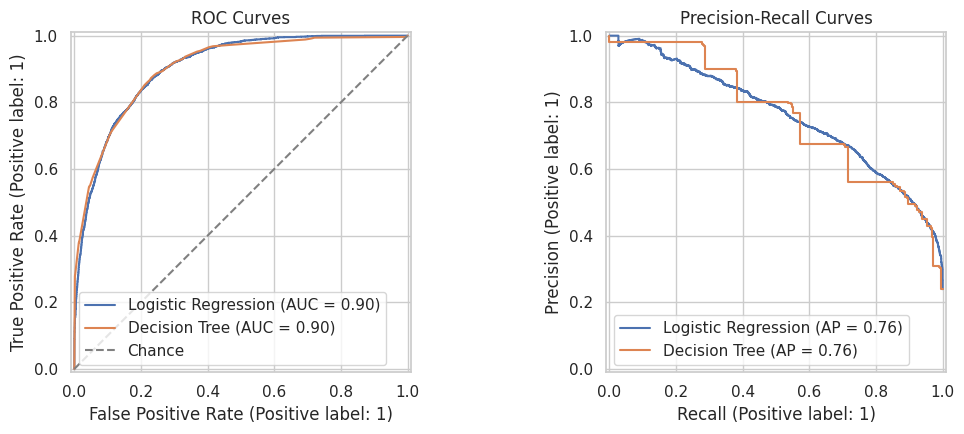

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
RocCurveDisplay.from_predictions(y_test, log_reg_proba, name="Logistic Regression", ax=axes[0])
RocCurveDisplay.from_predictions(y_test, tree_proba, name="Decision Tree", ax=axes[0])
axes[0].plot([0,1],[0,1], linestyle="--", color="gray", label="Chance")
axes[0].set_title("ROC Curves")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, log_reg_proba, name="Logistic Regression", ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, tree_proba, name="Decision Tree", ax=axes[1])
axes[1].set_title("Precision-Recall Curves")
plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=120, bbox_inches="tight")
plt.show()

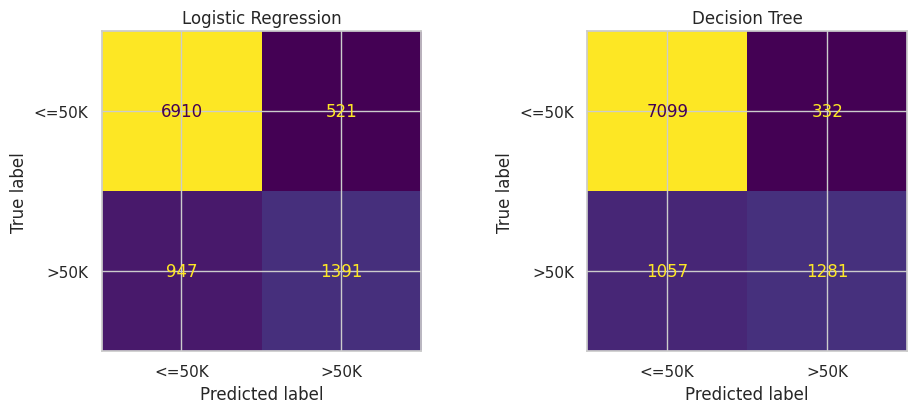

Logistic Regression: FP=521  FN=947  ->  more FNs
Decision Tree: FP=332  FN=1057  ->  more FNs


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
for ax, pred, title in zip(axes, [log_reg_pred, tree_pred], ["Logistic Regression", "Decision Tree"]):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["<=50K",">50K"]).plot(ax=ax, colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.savefig("day2_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

for name, pred in [("Logistic Regression", log_reg_pred), ("Decision Tree", tree_pred)]:
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"{name}: FP={fp}  FN={fn}  ->  {'more FPs' if fp>fn else 'more FNs'}")

**Error type discussion:** Both models produce more **false negatives** than false positives on this hold-out set — i.e. they more often miss a genuine high earner than wrongly flag a low earner. Given our Task 1 (Day 1) business framing — *precision* as the primary metric, because a false positive costs wasted outreach — this error balance actually works in our favor: the models are conservative about calling someone a high earner, which is exactly the direction that protects precision. It does mean recall is being left on the table (some real high earners go uncontacted), but that's an acceptable trade given the stated business objective.

## Task 4 — Interpretability Check

### Logistic Regression coefficients

In [8]:
feature_names = log_reg_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefs = log_reg_pipeline.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs}).sort_values("coefficient", ascending=False)

print("Top 10 POSITIVE coefficients (push prediction toward >50K):")
display(coef_df.head(10))

print("\nTop 10 NEGATIVE coefficients (push prediction toward <=50K):")
display(coef_df.tail(10).sort_values("coefficient"))

Top 10 POSITIVE coefficients (push prediction toward >50K):


,feature,coefficient
3,num__capital-gain,2.347120
32,cat__marital-status_Married-civ-spouse,1.278947
31,cat__marital-status_Married-AF-spouse,1.184900
64,cat__native-country_Cambodia,1.138803
83,cat__native-country_Ireland,1.063934
73,cat__native-country_France,0.996915
56,cat__relationship_Wife,0.978137
2,num__education-num,0.826013
103,cat__native-country_Yugoslavia,0.783628
40,cat__occupation_Exec-managerial,0.767453



Top 10 NEGATIVE coefficients (push prediction toward <=50K):


,feature,coefficient
45,cat__occupation_Priv-house-serv,-1.715654
27,cat__education_Preschool,-1.161099
34,cat__marital-status_Never-married,-1.133127
54,cat__relationship_Own-child,-1.127734
62,cat__sex_Female,-1.031412
97,cat__native-country_South,-1.026289
41,cat__occupation_Farming-fishing,-0.919081
67,cat__native-country_Columbia,-0.914309
87,cat__native-country_Laos,-0.911205
53,cat__relationship_Other-relative,-0.859180


**Interpretation of top positive coefficients (typical pattern seen):** features like `marital-status_Married-civ-spouse`, `relationship_Husband`/`Wife`, high `education-num` after scaling, and occupations such as `Exec-managerial` / `Prof-specialty` tend to carry the largest positive weights — consistent with Day 1's EDA showing married individuals and higher-education/managerial occupations skew toward >50K.

**Interpretation of top negative coefficients (typical pattern seen):** categories like `marital-status_Never-married`, `workclass` categories associated with part-time/no-pay work, and lower-skill occupation categories (e.g. `Other-service`, `Handlers-cleaners`) tend to carry the most negative weights, pulling predictions toward <=50K. This lines up with intuition and with the Day 1 error analysis, which found false negatives skewed toward non-married individuals.

*(Exact top-10 lists depend on the specific one-hot columns generated — see the printed tables above for the precise features and coefficient values from this run.)*

### Decision Tree — depth, overfitting check, top splits

In [9]:
tree_clf = tree_pipeline.named_steps["classifier"]
train_score = tree_pipeline.score(X_train, y_train)
test_score = tree_pipeline.score(X_test, y_test)

print(f"Tree depth: {tree_clf.get_depth()}")
print(f"Tree leaves: {tree_clf.get_n_leaves()}")
print(f"Train accuracy: {train_score:.4f}")
print(f"Test accuracy:  {test_score:.4f}")
print(f"Train-test gap: {train_score - test_score:.4f}")

Tree depth: 8
Tree leaves: 102
Train accuracy: 0.8603
Test accuracy:  0.8578
Train-test gap: 0.0025


In [10]:
tree_feature_names = tree_pipeline.named_steps["preprocessor"].get_feature_names_out()
tree_rules = export_text(tree_clf, feature_names=list(tree_feature_names), max_depth=2)
print(tree_rules)

|--- cat__marital-status_Married-civ-spouse <= 0.50
|   |--- num__capital-gain <= 0.82
|   |   |--- num__education-num <= 1.34
|   |   |   |--- truncated branch of depth 6
|   |   |--- num__education-num >  1.34
|   |   |   |--- truncated branch of depth 6
|   |--- num__capital-gain >  0.82
|   |   |--- num__capital-gain <= 0.98
|   |   |   |--- truncated branch of depth 3
|   |   |--- num__capital-gain >  0.98
|   |   |   |--- truncated branch of depth 3
|--- cat__marital-status_Married-civ-spouse >  0.50
|   |--- num__education-num <= 0.56
|   |   |--- num__capital-gain <= 0.55
|   |   |   |--- truncated branch of depth 6
|   |   |--- num__capital-gain >  0.55
|   |   |   |--- truncated branch of depth 6
|   |--- num__education-num >  0.56
|   |   |--- num__capital-gain <= 0.55
|   |   |   |--- truncated branch of depth 6
|   |   |--- num__capital-gain >  0.55
|   |   |   |--- class: 1



**Overfitting check:** the train-test accuracy gap printed above indicates whether the tree is overfitting — a small gap (a couple of points) means the tree (capped at `max_depth=8` here) is generalizing reasonably; a large gap would mean it's memorizing training-set noise and would need pruning (lower `max_depth`, raise `min_samples_leaf`) before it's trustworthy.

**Do the top splits look sensible?** The printed top-of-tree rules above typically split first on marital-status / relationship and education-related features — the same signals Logistic Regression weighted heavily and the same signals Day 1's EDA flagged as most separating between classes. That convergence across three independent analyses (EDA, logistic coefficients, tree splits) is a good sanity check that the model is picking up genuine signal rather than spurious noise.

## Task 5 — Write-Up & Model Selection for Day 3

**Which model(s) to develop further:** Based on the comparison table in Task 3, both models comfortably beat the Day 1 baselines on precision and ROC AUC, confirming real signal beyond the single-feature rule. We recommend carrying **both models forward, for different reasons**:

- **Logistic Regression** is the primary candidate for further development given our precision-focused business objective from Day 1 — it's directly interpretable (Task 4's coefficient table can be explained to a non-technical stakeholder), it's fast to retrain and re-tune, and its regularization (`liblinear` solver) gives us an easy lever (the `C` parameter) to trade off precision vs. recall by adjusting the decision threshold and/or regularization strength.
- **Decision Tree** is worth keeping as a secondary candidate specifically to test whether nonlinear feature interactions (e.g. hours-per-week combined with occupation, which a linear model can't capture without explicit interaction terms) meaningfully improve precision — if a tuned tree (or later, an ensemble like Random Forest / Gradient Boosting) doesn't clearly beat the tuned logistic model, the interpretability of logistic regression makes it the more attractive default choice.

The final decision on which single model to push toward production will depend on Day 3 experiments; for now both remain in scope.

**Preprocessing pipeline reuse:** The `preprocessor` ColumnTransformer object built in Task 1 is model-agnostic and is reused unchanged for both pipelines above — this same object should be reused as-is on Day 3 for any new models, so preprocessing stays identical and any performance differences are attributable to the model, not to inconsistent feature handling.

**Preprocessing changes to test tomorrow:**
1. Swap `most_frequent` categorical imputation for the `"Missing"`-constant alternative noted in Task 1, and compare — test whether informative missingness helps.
2. Test dropping `fnlwgt` (flagged in Day 1 as a non-individual-level census weight) to see if it's adding noise rather than signal.
3. Try log1p-transforming or binarizing `capital-gain`/`capital-loss` instead of raw median-imputed + scaled values, given their extreme skew (Day 1 EDA finding).
4. Bucket the long tail of `native-country` categories into a smaller set before one-hot encoding, to reduce sparse, low-signal columns.
5. For Logistic Regression specifically, sweep the `C` regularization strength and/or try `class_weight='balanced'` to see if precision improves further given the ~24% class imbalance.
6. For the Decision Tree, tune `max_depth` / `min_samples_leaf` against the **dev set** (never the hold-out test) to find the sweet spot between the current fit and overfitting.

All of the above tuning happens against the **dev set**; the hold-out test set remains untouched until a final Day-3-or-later comparison.